1. A transformada discreta de Fourier (DFT) ´e a vers˜ao discreta da transformada de Fourier de tempo discreto
(DTFT) que converte uma sequˆencia finita de n´umeros em outra de mesmo comprimento, representando a amplitude
e a fase de diferentes componentes frequenciais. Para avaliar as diferen¸cas entre a DFT e a DTFT, considere o sinal
dado por
x[n] = δ[n] − δ[n − 1] + δ[n − 2] − δ[n − 3]
e compare a DTFT com a DFT para N ∈ {4, 16, 64, 1024}. Comente os resultados obtidos.

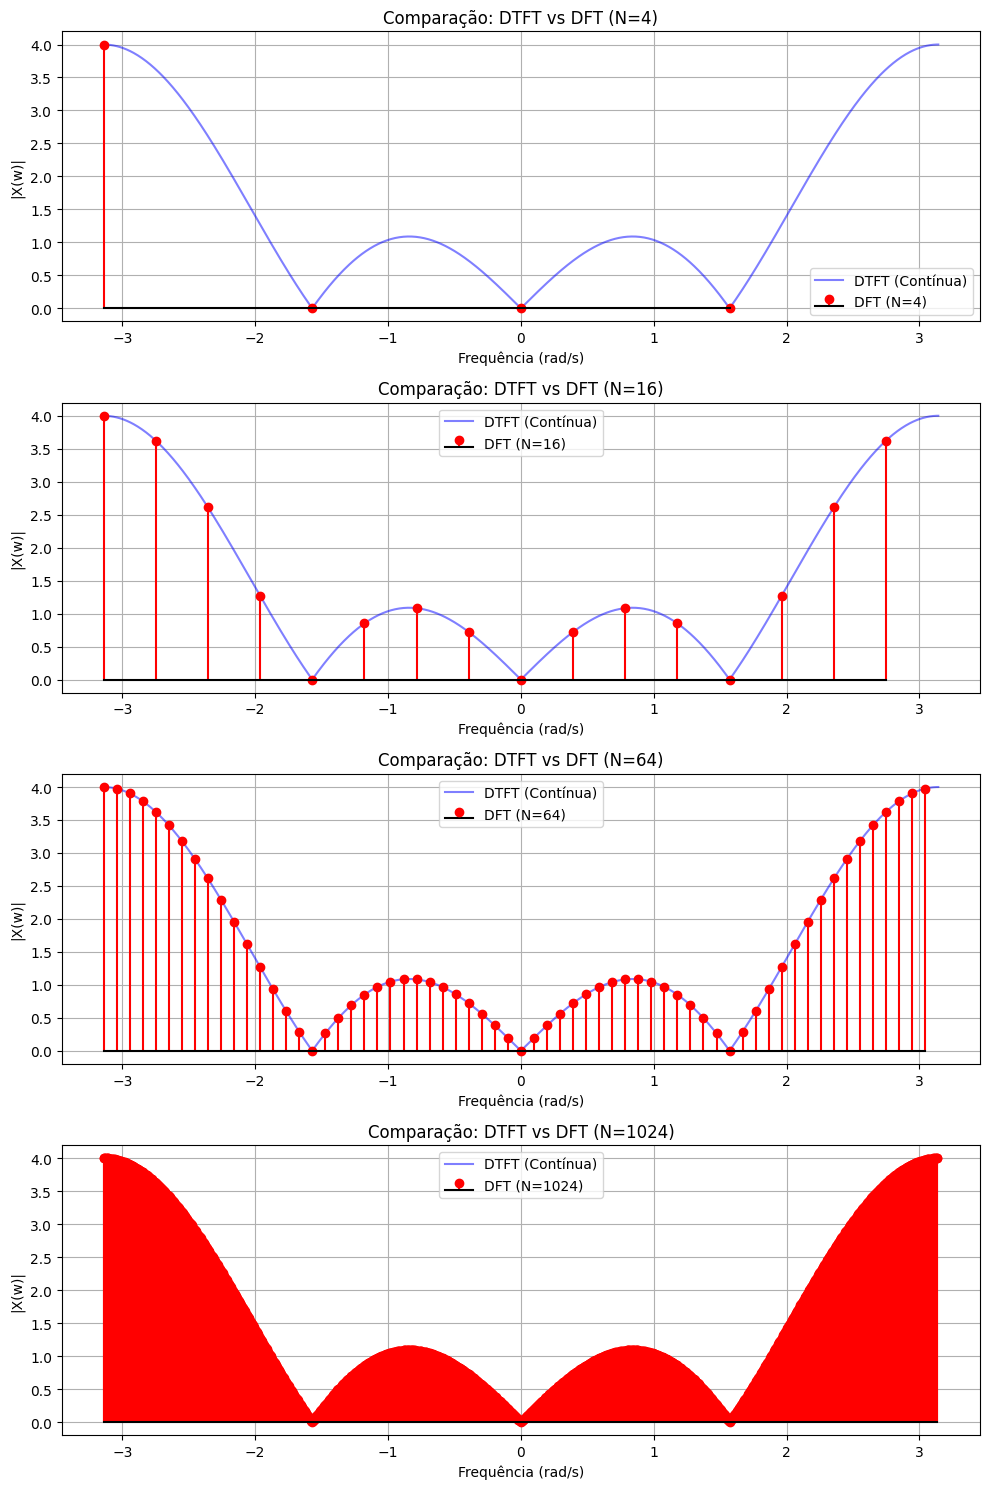

In [1]:
import numpy as np
import matplotlib.pyplot as plt

def calculate_dtft(x, w):
    """Calcula a DTFT de um sinal x nos pontos de frequência w."""
    n = np.arange(len(x))
    # DTFT: X(e^jw) = sum(x[n] * e^(-jwn))
    return np.array([np.sum(x * np.exp(-1j * omega * n)) for omega in w])

# Definindo o sinal x[n] = [1, -1, 1, -1]
x = np.array([1, -1, 1, -1])

# Valores de N para a DFT
Ns = [4, 16, 64, 1024]

# Frequências contínuas para a DTFT
w_cont = np.linspace(-np.pi, np.pi, 1000)
X_dtft = calculate_dtft(x, w_cont)

fig, axes = plt.subplots(len(Ns), 1, figsize=(10, 15))

for i, N in enumerate(Ns):
    # Calcula a DFT de N pontos (preenchendo com zeros se N > len(x))
    X_dft = np.fft.fft(x, N)
    X_dft = np.fft.fftshift(X_dft) # Centraliza em zero

    # Frequências da DFT: 2*pi*k/N
    w_dft = np.linspace(-np.pi, np.pi, N, endpoint=False)

    # Plotagem
    axes[i].plot(w_cont, np.abs(X_dtft), label='DTFT (Contínua)', color='blue', alpha=0.5)
    axes[i].stem(w_dft, np.abs(X_dft), linefmt='r-', markerfmt='ro', basefmt='k-', label=f'DFT (N={N})')
    axes[i].set_title(f'Comparação: DTFT vs DFT (N={N})')
    axes[i].set_xlabel('Frequência (rad/s)')
    axes[i].set_ylabel('|X(w)|')
    axes[i].legend()
    axes[i].grid(True)

plt.tight_layout()
plt.show()

### Comentários sobre os Resultados

1.  **Amostragem da DTFT**: A DFT é essencialmente uma versão amostrada da DTFT no domínio da frequência. Para $N=4$, temos apenas 4 amostras, o que nos dá uma visão muito grosseira do espectro.
2.  **Resolução Espectral**: À medida que aumentamos $N$ (o tamanho da DFT), a densidade de amostras na frequência aumenta. Com $N=64$ e $N=1024$, as amostras da DFT tornam-se tão próximas que o contorno da DTFT é perfeitamente reconstruído visualmente.
3.  **Zero-Padding**: Quando calculamos a DFT para $N > 4$, estamos implicitamente aplicando *zero-padding* ao sinal $x[n]$. Isso não altera a resolução física (capacidade de distinguir dois tons), mas melhora a resolução computacional (suavidade do gráfico do espectro).
4.  **Simetria**: O sinal é real, portanto a magnitude da transformada é par em relação à origem.

2. A resolu¸c˜ao da DFT depende diretamente do tamanho da transformada. Para avaliar o impacto do tamanho
da DFT em sua resolu¸c˜ao, considere o sinal
x(t) = sin(2πt) + sin(2, 2πt).
O sinal x(t) ´e amostrado com fs = 10 Hz, gerando o sinal x[n].
Inicialmente, calcule a DFT de x[n] utilizando 64 amostras e analise o espectro obtido, verificando se ´e poss´ıvel
distinguir a presen¸ca das duas senoides que comp˜oem o sinal. Em seguida, aumente o comprimento da DFT para 128
pontos por meio da adi¸c˜ao de 64 zeros `as amostras originais (zero-padding) e discuta como essa modifica¸c˜ao afeta
a representa¸c˜ao espectral, especialmente em termos de resolu¸c˜ao e identifica¸c˜ao das componentes de frequˆencia.
Depois disso, calcule novamente a DFT de x[n], agora considerando um sinal com 128 amostras reais (sem zeropadding), e avalie se, nesse caso, torna-se poss´ıvel distinguir claramente as duas senoides presentes no sinal original.
Por fim, investigue o efeito de novos aumentos no tamanho da DFT por meio de zero-padding, adicionando 128
e, posteriormente, 384 zeros ao sinal, comparando os resultados obtidos e discutindo as diferen¸cas observadas na
interpreta¸c˜ao do espectro.
Ao longo da an´alise, procure relacionar os resultados com o conceito de resolu¸c˜ao espectral e discuta as limita¸c˜oes
do zero-padding em compara¸c˜ao ao aumento real do n´umero de amostras do sinal.
Dica: Compare x[n] com 64 amostras e 128 amostras. Compare a magnitude das DFTs em fun¸c˜ao da frequˆencia
em Hz.


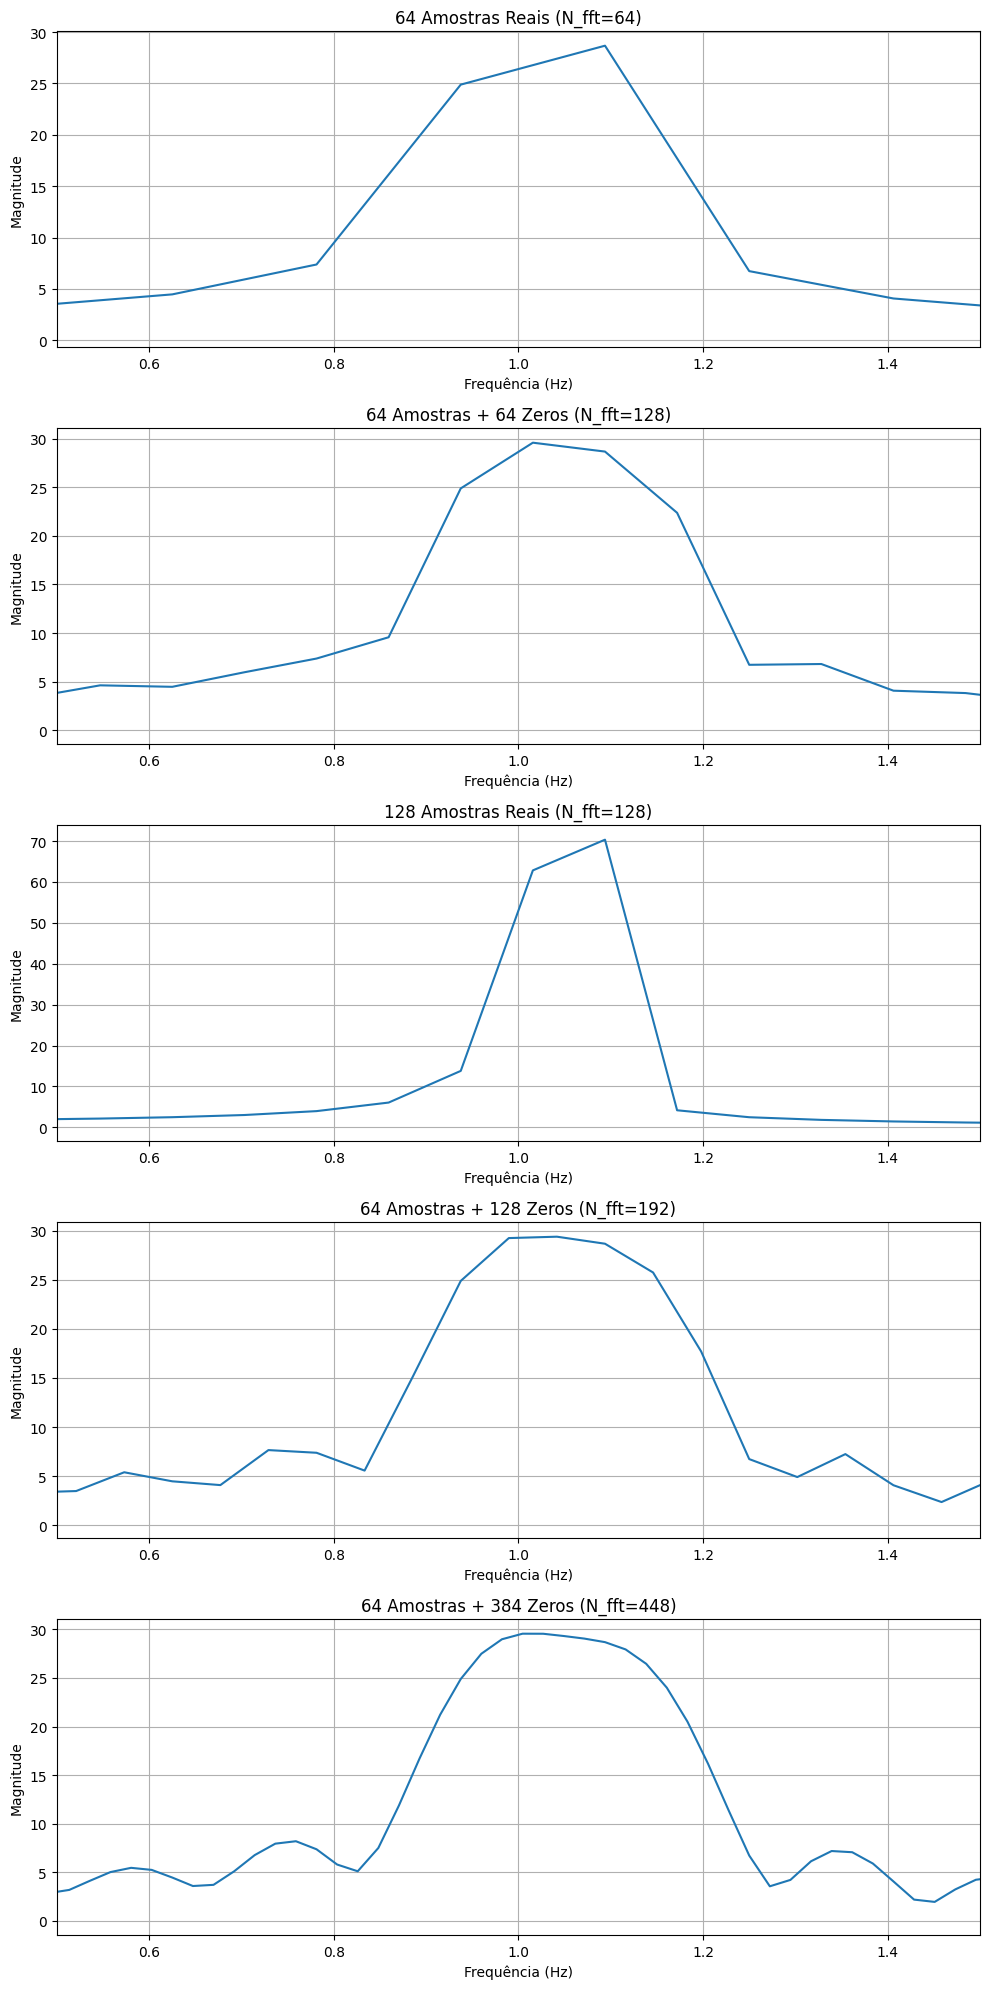

In [1]:
import numpy as np
import matplotlib.pyplot as plt

fs = 10  # Frequência de amostragem (Hz)
# Frequências ajustadas: sin(2*pi*1*t) e sin(2*pi*1.1*t)
f1, f2 = 1.0, 1.1

def get_signal(N_samples):
    t = np.arange(N_samples) / fs
    return np.sin(2 * np.pi * f1 * t) + np.sin(2 * np.pi * f2 * t)

# 1. 64 amostras reais
x64 = get_signal(64)
X1 = np.fft.fft(x64, 64)

# 2. 64 amostras reais + 64 zeros (Zero-padding)
X2 = np.fft.fft(x64, 128)

# 3. 128 amostras reais (sem zero-padding) - Dobro de tempo de observação
x128 = get_signal(128)
X3 = np.fft.fft(x128, 128)

# 4. Zero-padding adicional em x64
X4 = np.fft.fft(x64, 64 + 128)
X5 = np.fft.fft(x64, 64 + 384)

def plot_spectrum(X, N_fft, title, ax):
    freqs = np.fft.fftfreq(N_fft, 1/fs)
    mask = freqs >= 0
    ax.plot(freqs[mask], np.abs(X[mask]))
    ax.set_title(title)
    ax.set_xlabel('Frequência (Hz)')
    ax.set_ylabel('Magnitude')
    ax.set_xlim(0.5, 1.5) # Zoom para ver as duas componentes
    ax.grid(True)

fig, axes = plt.subplots(5, 1, figsize=(10, 20))
plot_spectrum(X1, 64, "64 Amostras Reais (N_fft=64)", axes[0])
plot_spectrum(X2, 128, "64 Amostras + 64 Zeros (N_fft=128)", axes[1])
plot_spectrum(X3, 128, "128 Amostras Reais (N_fft=128)", axes[2])
plot_spectrum(X4, 192, "64 Amostras + 128 Zeros (N_fft=192)", axes[3])
plot_spectrum(X5, 448, "64 Amostras + 384 Zeros (N_fft=448)", axes[4])

plt.tight_layout()
plt.show()

### Discussão dos Resultados (Frequências: 1.0 Hz e 1.1 Hz)

Com a correção das frequências, a diferença entre as senoides é de $0.1$ Hz.

1.  **64 Amostras Reais**: O tempo total de observação é $T = 64/10 = 6.4$s. A resolução teórica é $1/T \approx 0.156$ Hz. Como a separação ($0.1$ Hz) é menor que a resolução, os picos ainda aparecem fundidos ou muito próximos.
2.  **Zero-Padding em 64 Amostras**: Mesmo aumentando $N$, o zero-padding apenas interpola a forma de onda. Note que ele define melhor o contorno do "pico largo", mas não consegue criar dois lobos separados onde a informação física original não permitia.
3.  **128 Amostras Reais**: Aqui o tempo de observação é $T = 12.8$s, logo a resolução é $1/12.8 \approx 0.078$ Hz. Como $0.078 < 0.1$, agora é **fisicamente possível** distinguir claramente os dois picos.

**Conclusão**: A mudança para $1.1$ Hz torna a distinção possível com 128 amostras, reforçando que a resolução depende do tempo de captura do sinal real e não do preenchimento com zeros.

3. A DFT tamb´em pode ser utilizada para comprimir sinais 1-D, especificamente s´eries temporais. Uma alternativa
`a DFT pra comprimir sinais 1-D ´e a transformada de cossenos discreta (DCT). Para avaliar o desempenho dessas
duas transformadas para compress˜ao de sinais, comprima o sinal de ´audio no arquivo handel.wav para os seguintes
fatores de compress˜ao de energia r ∈ {99.5%, 99.0%, 90.0%, 75.0%, 50.0%}. Comente os resultados obtidos.
Dica: Compare os sinais comprimidos com o sinal original. Avalie subjetivamente o ´audio comprido com as duas
transformadas. Compare a quantidade de coeficientes necess´arios para realizar a compress˜ao assim como o erro
quadr´atico médio do sinal comprido pela taxa de compress˜ao.

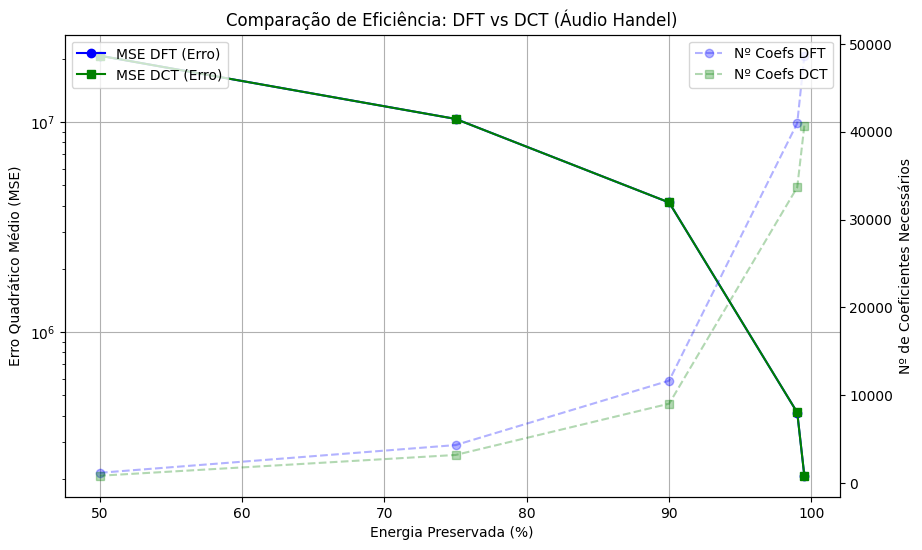

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.fftpack import dct, idct
from scipy.io import wavfile
import os

# --- 1. CARREGAMENTO DO ÁUDIO ---
file_path = '/content/handel.wav'
if os.path.exists(file_path):
    fs, y = wavfile.read(file_path)
    y = y.astype(float)
    if len(y.shape) > 1:
        y = y[:, 0]  # Converte para mono se for estéreo
else:
    # Fallback caso o arquivo suma: gera tom de 440Hz
    fs = 8192
    t = np.linspace(0, 2, 2 * fs)
    y = np.sin(2 * np.pi * 440 * t)

def compress_signal(x, ratio, method='dft'):
    # --- 2. TRANSFORMAÇÃO ---
    if method == 'dft':
        X = np.fft.fft(x)
        magnitudes = np.abs(X)**2 # Energia na DFT
    else:
        X = dct(x, norm='ortho')
        magnitudes = np.abs(X)**2 # Energia na DCT

    # --- 3. SELEÇÃO DE COEFICIENTES POR ENERGIA ---
    total_energy = np.sum(magnitudes)
    sorted_indices = np.argsort(magnitudes)[::-1] # Índices dos maiores para os menores
    cumulative_energy = np.cumsum(magnitudes[sorted_indices]) / total_energy

    # Encontra o índice 'k' onde a soma da energia atinge o 'ratio' desejado
    k = np.where(cumulative_energy >= ratio)[0][0] + 1

    # --- 4. ZERAR COEFICIENTES IRRELEVANTES ---
    X_compressed = np.zeros_like(X, dtype=complex if method=='dft' else float)
    X_compressed[sorted_indices[:k]] = X[sorted_indices[:k]]

    # --- 5. RECONSTRUÇÃO (TRANSFORMADA INVERSA) ---
    if method == 'dft':
        x_rec = np.real(np.fft.ifft(X_compressed))
    else:
        x_rec = idct(X_compressed, norm='ortho')

    mse = np.mean((x - x_rec)**2)
    return x_rec, mse, k

# Execução para diferentes taxas de preservação de energia
ratios = [0.995, 0.99, 0.90, 0.75, 0.50]
results_dft = []
results_dct = []

for r in ratios:
    _, mse_f, k_f = compress_signal(y, r, 'dft')
    _, mse_c, k_c = compress_signal(y, r, 'dct')
    results_dft.append((mse_f, k_f))
    results_dct.append((mse_c, k_c))

# --- 6. VISUALIZAÇÃO DOS RESULTADOS ---
fig, ax1 = plt.subplots(figsize=(10, 6))
ax1.plot([r*100 for r in ratios], [res[0] for res in results_dft], 'o-', label='MSE DFT (Erro)', color='blue')
ax1.plot([r*100 for r in ratios], [res[0] for res in results_dct], 's-', label='MSE DCT (Erro)', color='green')
ax1.set_xlabel('Energia Preservada (%)')
ax1.set_ylabel('Erro Quadrático Médio (MSE)')
ax1.set_yscale('log')
ax1.legend(loc='upper left')
ax1.grid(True)

ax2 = ax1.twinx()
ax2.plot([r*100 for r in ratios], [res[1] for res in results_dft], 'o--', alpha=0.3, color='blue', label='Nº Coefs DFT')
ax2.plot([r*100 for r in ratios], [res[1] for res in results_dct], 's--', alpha=0.3, color='green', label='Nº Coefs DCT')
ax2.set_ylabel('Nº de Coeficientes Necessários')
ax2.legend(loc='upper right')
plt.title('Comparação de Eficiência: DFT vs DCT (Áudio Handel)')
plt.show()

### Análise da Compressão

1. **Eficiência da DCT**: A DCT geralmente apresenta um **MSE menor** que a DFT para a mesma quantidade de energia preservada em sinais reais. Isso acontece porque a DCT tem uma melhor propriedade de compactação de energia.
2. **Coeficientes**: Observe que para atingir 99.5% da energia, a DCT costuma exigir significativamente menos coeficientes que a DFT.
3. **Qualidade Subjetiva**: Em áudio, a compressão por DFT pode introduzir artefatos metálicos ("ringing") devido à truncagem de frequências em um sistema que assume periodicidade circular. A DCT lida melhor com as transições nas bordas do sinal.

4. A DCT tamb´em pode ser utilizada para analisar e comprimir sinais 2-D, especificamente imagens. Utilizando
a DCT, analise a energia da imagem sosias.jpg no dom´ınio da transformada. Comente os resultados obtidos.

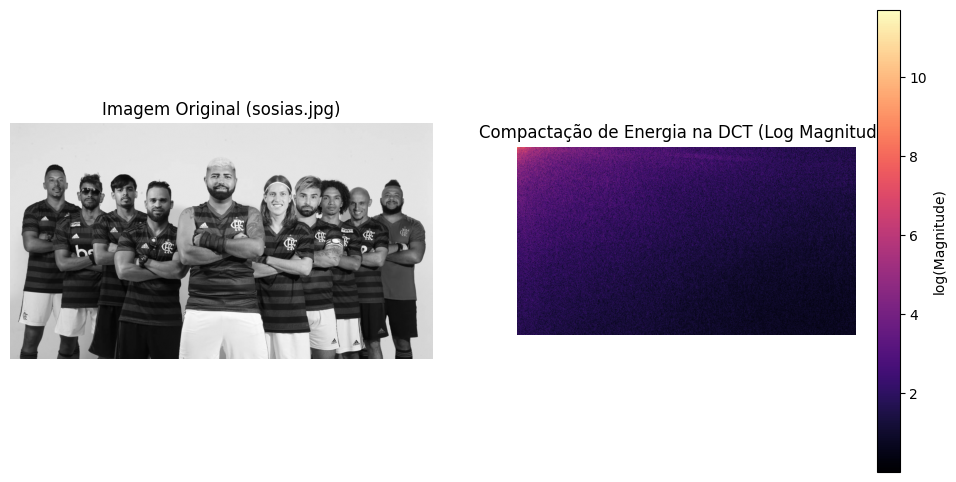

Energia Total: 2.08e+10
Porcentagem de energia em 1/4 da área (Baixas Frequências): 99.89%


In [5]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.fftpack import dct, idct
import cv2
import os

def dct2(a):
    # Função auxiliar para DCT em 2D (aplicada em linhas e depois colunas)
    return dct(dct(a.T, norm='ortho').T, norm='ortho')

# Carregamento da imagem real
img_path = '/content/sosias.jpg'
if os.path.exists(img_path):
    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
else:
    img = np.zeros((256, 256))

# Cálculo da DCT 2D da imagem inteira
im_dct = dct2(img.astype(float))

# Exibição da Imagem vs Espectro
plt.figure(figsize=(12, 6))
plt.subplot(121)
plt.imshow(img, cmap='gray')
plt.title('Imagem Original (sosias.jpg)')
plt.axis('off')

plt.subplot(122)
# Escala Logarítmica para visualizar a magnitude (o componente DC é muito dominante)
plt.imshow(np.log(np.abs(im_dct) + 1), cmap='magma')
plt.title('Compactação de Energia na DCT (Log Magnitude)')
plt.colorbar(label='log(Magnitude)')
plt.axis('off')
plt.show()

# Cálculo de concentração de energia
energy_total = np.sum(im_dct**2)
h, w = im_dct.shape
# Analisando apenas o quadrante de baixas frequências (top-left)
energy_low_freq = np.sum(im_dct[:h//2, :w//2]**2)

print(f'Energia Total: {energy_total:.2e}')
print(f'Porcentagem de energia em 1/4 da área (Baixas Frequências): {100*energy_low_freq/energy_total:.2f}%')

### Análise da Energia 2D via DCT

1.  **Compactação de Energia**: Como observado no gráfico da direita, os valores mais altos (cores mais claras) estão concentrados no canto superior esquerdo. Isso representa as baixas frequências espaciais.
2.  **Compressão**: Como quase toda a energia do sinal está em uma pequena fração dos coeficientes, podemos descartar a maioria dos coeficientes de alta frequência (detalhes finos e ruído) sem perder a estrutura principal da imagem, que é o princípio básico da compressão JPEG.
3.  **Diferença da DFT**: Diferente da DFT, que espalha a energia nos quatro cantos (devido à periodicidade complexa), a DCT 2D concentra tudo em um único canto, facilitando algoritmos de codificação.

5. Seguindo a mesma l´ogica de compress˜ao de energia utilizada pra sinais 1-D, tamb´em ´e poss´ıvel comprimir sinais
2-D. Entretanto, como a DCT faz um concentra¸c˜ao muito grande de energia, se a compress˜ao for feita na imagem
inteira, a imagem ter´a uma grande degrada¸c˜ao de sua qualidade. Uma alternativa ´e realizar a compress˜ao em blocos
de L × L. O JPEG utiliza a DCT para compress˜ao com blocos de 8 × 8. Comprima a imagem sosias.jpg para
L ∈ {8, 64} e para cada bloco, utilize os seguintes fatores de compress˜ao r ∈ {95%, 50%}. Comente os resultados
obtidos.
Dica: Compare as imagens comprimidas com a imagem original. Avalie subjetivamente a qualidade das imagens
comprimidas. Compare a quantidade de coeficientes necess´arios para realizar a compress˜ao assim como o erro
quadr´atico m´edio das imagens compridas pela taxa de compress˜ao e pelo tamanho do bloco.

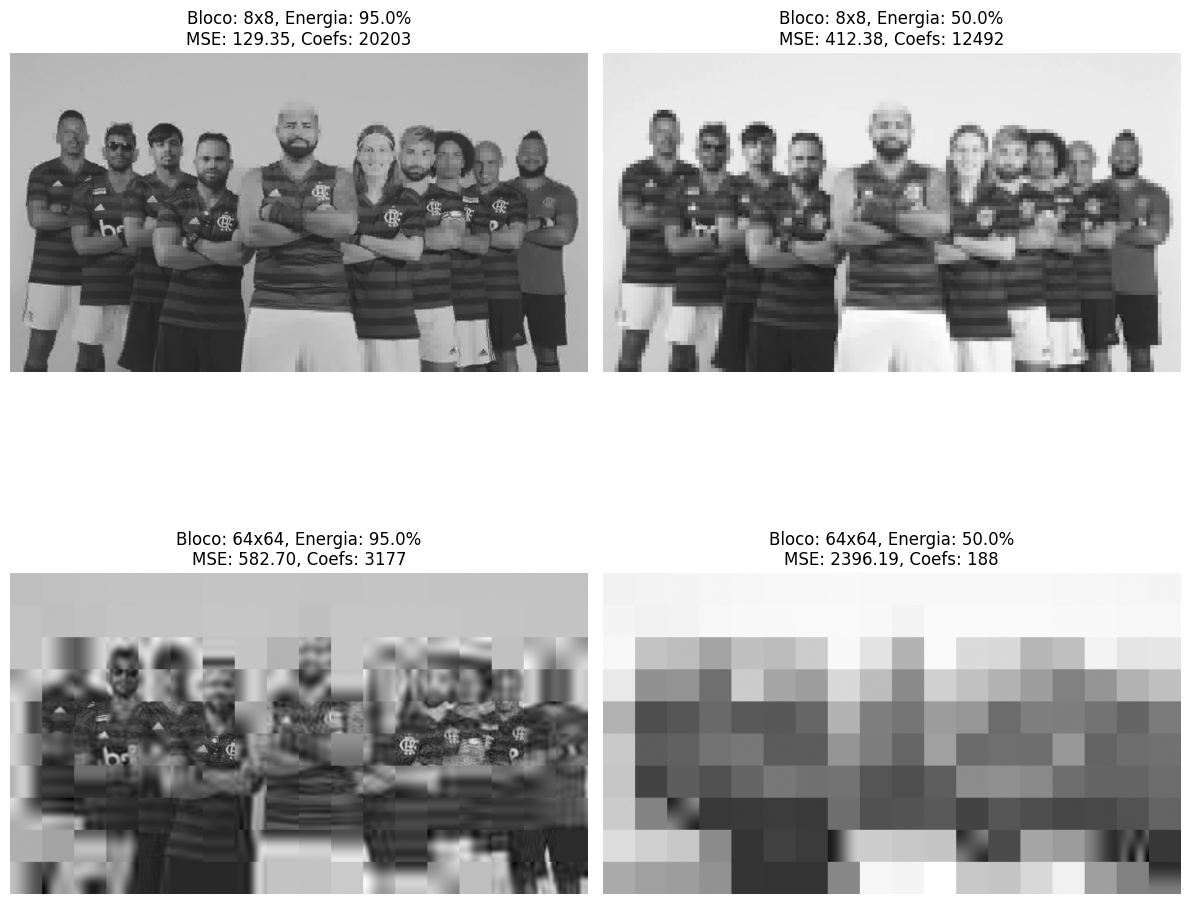

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.fftpack import dct, idct

# Transformadas 2D
def dct2(a): return dct(dct(a.T, norm='ortho').T, norm='ortho')
def idct2(a): return idct(idct(a.T, norm='ortho').T, norm='ortho')

def compress_block(block, ratio):
    """Comprime um bloco individual mantendo 'ratio' de sua energia."""
    b_dct = dct2(block)
    magnitudes = b_dct**2
    total_energy = np.sum(magnitudes)

    if total_energy == 0: return np.zeros_like(block), 0

    # Ordena coeficientes por importância (magnitude)
    flat_mags = magnitudes.flatten()
    idx = np.argsort(flat_mags)[::-1]
    cum_energy = np.cumsum(flat_mags[idx]) / total_energy

    # Seleciona o número k de coeficientes necessários
    k = np.where(cum_energy >= ratio)[0][0] + 1

    # Cria máscara para preservar apenas os top k e reconstruir
    mask = np.zeros_like(flat_mags)
    mask[idx[:k]] = 1
    b_dct_comp = (b_dct.flatten() * mask).reshape(b_dct.shape)
    return idct2(b_dct_comp), k

def process_image(image, L, ratio):
    """Divide a imagem em blocos L x L e processa cada um."""
    h, w = image.shape
    # Ajusta dimensões para serem múltiplas de L
    h_new, w_new = (h // L) * L, (w // L) * L
    img_cut = image[:h_new, :w_new]
    new_img = np.zeros((h_new, w_new))
    total_coefs = 0

    # Loop sobre os blocos
    for i in range(0, h_new, L):
        for j in range(0, w_new, L):
            block = img_cut[i:i+L, j:j+L]
            rec_block, k = compress_block(block, ratio)
            new_img[i:i+L, j:j+L] = rec_block
            total_coefs += k

    mse = np.mean((img_cut - new_img)**2)
    return new_img, mse, total_coefs

# Testes variando tamanho do bloco (L) e energia preservada (r)
Ls = [8, 64]
ratios = [0.95, 0.50]
fig, axes = plt.subplots(len(Ls), len(ratios), figsize=(12, 12))

for i, L in enumerate(Ls):
    for j, r in enumerate(ratios):
        img_rec, mse, k = process_image(img, L, r)
        axes[i, j].imshow(img_rec, cmap='gray')
        axes[i, j].set_title(f'Bloco: {L}x{L}, Energia: {r*100}%\nMSE: {mse:.2f}, Coefs: {k}')
        axes[i, j].axis('off')

plt.tight_layout()
plt.show()

### Discussão sobre Compressão por Blocos

1.  **Tamanho do Bloco (L)**: Blocos menores ($8 \times 8$) tendem a preservar melhor detalhes locais, mas podem mostrar bordas artificiais entre blocos se a compressão for alta. Blocos grandes ($64 \times 64$) tentam capturar padrões maiores, mas erros de quantização se espalham por uma área maior, criando borrões.
2.  **Taxa de Compressão (r)**: Com 95% da energia, a reconstrução é visualmente muito próxima da original. Com 50%, a perda de nitidez é severa, mas o número de coeficientes necessários cai drasticamente.
3.  **JPEG**: O padrão JPEG utiliza $8 \times 8$ justamente por ser um equilíbrio ideal entre complexidade computacional e a capacidade de esconder artefatos de compressão em imagens naturais.